#MS285 Final Project
#Keeler Nelsen
In this notebook, I will describe my final project for MS285.

**Questions**

1. Can machine learning calculate MaxN of Rockfish species?
2. Does this MaxN, match what was found by a human observer?

**Motivation**

I am interested in using machine learning to help humans annotate video. Humans spend tons of time watching video recorded by ROVs, BRUVs, and landers to indentify and enumerate species of interest. Personally, I am interested in Rockfish species because that is primarily what we see in the CCFRP catch data. For my thesis, I will be recording video from above a lure and enumerating fish interactions with a lure. I hope to be able to use machine learning to identify Rockfish species and enumerate them in video frames to calculate MaxN of rockfish species.

**Data**

Jake Todd, a recent graduate from MMLML, used mini-landers (metal frame with stereo gopro video) to record fish species in different habitat types in order to draw conclusions on how habitat and wave energy regimes affect the makeup of fish assemblages. The video he collected includes a limited view of the benthos and records fish as they swim by. Each video is an hour long and he recorded hundreds of videos. I will annotate a few of his videos to create a training dataset of labeled images with classes; Fish, Rockfish, and other. The fish will be labeled when it is a fish but cannot be identified as a Rockfish and the Rockfish label will be used when it can be positively identified as a Rockfish.

**Model**

I am planning to use a YOLO model from Ultralytics. This model is appropriate to use on my dataset because I want to identify multiple objects per image and train the model on the labeled objects instead of the whole frame. YOLO is the best and easiest model to train using this type of data. I will train the model using the training dataset I manually annotated. The loss function used by YOLO models is different for each of the model iterations, but the YOLOv8 model I am planning on using uses both Box Loss (CIoU Loss and Distribution Focal Loss) and Classification Loss (Binary Cross-Entropy).

**Analysis**

First, I will train the model on the training dataset and use another smaller set of labeled images to validate and test the models performance. Based on this validation/test dataset, the model will provide a performance which will hopefully decrease over time.

Next, I will use the trained model to indentify and enumerate the fish in a new video and I will extract the number of fish and Rockfish the model identified in each video frame. I will then review the results of the models performance and make any corrections. I will also compare this to the species MaxN calculated by Jake Todd. The differences of the model and Jake's MaxN will tell me how the model does.

#_____________________________________________________________________________
#NOW FOR SOME CODE

#SET UP DATA
**Import Modules**

In [ ]:
# base modules
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import cv2
import shutil
from IPython.display import Video
from sklearn.model_selection import train_test_split

**Directory Set Up**

In [ ]:
home_dir = os.path.expanduser('~')

In [ ]:
if home_dir=='/root':
    os.system('pip install ultralytics')
    os.system('pip install pyyaml')
from ultralytics import YOLO
import yaml

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
if home_dir!='/root':
    working_dir = os.getcwd()  # on local machine, just use this directory

If we are on Google Colab, use Google Drive on Colab:

In [ ]:
if home_dir=='/root':
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


**Directory to Data in Google Drive**

In [ ]:
if home_dir=='/root':
    working_dir = '/content/drive/MyDrive/MS285/final_project'

## A GLIMPSE INTO THE RAW VIDEO





In [ ]:
import os
from IPython.display import Video, display
display(Video(os.path.join(working_dir,'Example_Rockfish_Video.mp4'), width=800,height=600, embed=True))

## MODEL DESIGN

### Creating training labels and extracting frames

I found a free, public model online called Community Fish Detector that is trained on a bunch of public fish image datasets from all over the world and from many different ecosystems. The purpose of the model is just to identify one class: Fish.

Initially, I ran this model on the video to draw bounding boxes on fish on every second of the video. Extracting a frame every second is called striding, instead of running the model on every single frame of the video. This inference output a frame for every 1 second of video with an associated .txt file in the YOLO format that included the bounding boxes and class label (FISH) as long as the model confidence was more than 0.09.


Below is the code that uses the community fish detector model to draw bounding boxes on our images. This cell will probably take awhile to run.

In [ ]:
from ultralytics import YOLO
import os
import cv2

# Paths
model_path = os.path.join(working_dir, "cfd-yolov12x-1.00.pt")
video_path = os.path.join(working_dir, "20220726_ButterflyHouse_D14.01_1L_1 copy.MP4")

out_frames = os.path.join(working_dir, "Initial_frames")
out_labels = os.path.join(working_dir, "Initial_labels")

os.makedirs(out_frames, exist_ok=True)
os.makedirs(out_labels, exist_ok=True)

# Load model
model = YOLO(model_path)

# Run prediction
results = model.predict(
    source=video_path,
    agnostic_nms=True,
    save=False,
    save_txt=False,   # we're saving txt ourselves below
    conf=0.09, #we keep confidence low so that the model is not too picky
    iou=0.15,
    imgsz=1080,
    max_det=1000,
    half=True,
    classes=[0, 1, 2, 3],
    vid_stride=60, #takes a frame very second
    device="cuda",
    stream=True
)

for i, r in enumerate(results):
    base = f"frame_{i:06d}"

    # 1) Save clean frame (no boxes)
    img_path = os.path.join(out_frames, f"{base}.jpg")
    cv2.imwrite(img_path, r.orig_img)

    # 2) Save matching YOLO label file
    txt_path = os.path.join(out_labels, f"{base}.txt")

    lines = []
    if r.boxes is not None and len(r.boxes) > 0:
        # normalized xywh (0-1) in YOLO format
        xywhn = r.boxes.xywhn.cpu().numpy()
        cls = r.boxes.cls.cpu().numpy().astype(int)

        for c, (x, y, w, h) in zip(cls, xywhn):
            lines.append(f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")

    with open(txt_path, "w") as f:
        f.write("\n".join(lines))


WARNING ⚠️ imgsz=[1080] must be multiple of max stride 32, updating to [1088]


KeyboardInterrupt: 

Next, I used a software called RectLabel. In RectLabel, I imported the frames and the YOLO labels. I then went through the labels generated by the Community Fish Detector model to make changes, label things it missed, and delete things it labeled that were not fish. I went in and either changed the label or created a new label for all of the Rockfish I could positively identify as Rockfish. I also changed the labels that were incorrectly assigned to algae or other things that were not fish. After correcting the labels, I exported the new labels alongside the images.

**Example YOLO Label**

In [ ]:
label_path = os.path.join(working_dir,'Fish_Sebastest_Other_04162026/labels/frame_000045.txt')
labels = np.genfromtxt(label_path, delimiter=' ')
print(labels)

[[          0     0.70496    0.066432    0.022059     0.04136]
 [          2    0.058594      0.7549    0.028608    0.050654]]


Instead of starting with a pretrained model like I did, you can also extract a frame from every second of video and label all of them manually. You will end up with the same result, but it may take longer. This label is from after I went through and created more classes. The structure is the same as the output of using fish detector model, but I have created more classes than just 'Fish'

##The next step is to take the labeled dataset you have created and train a machine learning model!

## You Only Look Once
**DESCRIPTION FROM MS285 LECTURE**

YOLO (You Only Look Once) is an object detection model that is used to predict bounding boxes and class probabilities directly from an input image using a convolutional neural network. The model is called YOLO because it identifies the bounding box and the classification at the same time unlike two-stage detectors that first generate a region of interest in an image using one model and then classifies the image subset in another model. The YOLO architecture has a "backbone" for feature extraction, a "neck" for feature aggregation, and a detection "head" for predicting box coordinates and class labels. YOLO models have undergone significant development in recent years and are used in a lot of applications in marine science, particularly for identifying organisms in footage.

### Fine-Tuning a Pre-trained YOLO Model
**DESCRIPTION FROM MS285 LECTURE**

YOLO models have been trained by other researchers on a wide range of images to give a set of weights that do reasonably-well on a variety of tasks. Here, we would like to take a pre-trained model, and fine-tune it for our purposes. The company [Ultralytics](https://www.ultralytics.com/) has provided some tools to load and fine-tune some of their old pre-trained models. At the time of this writing, the most recent YOLO model is version 26 - we will go way back and take a look at version 8 for our example. Even though this is not the most recent model, it is still quite a large model that can perform well on our fish detection task.

#### Loading a pre-trained model:
To load in some of the pre-trained weights for the YOLOv8 model, we use the following line:

In [ ]:
model = YOLO('yolov8s.pt')

**Splitting dataset into training and validation sets**

In [ ]:
# make some directories for the data
os.makedirs(os.path.join(working_dir,'model','train'), exist_ok=True)
os.makedirs(os.path.join(working_dir,'model','val'), exist_ok=True)

# split the images into training and testing
image_files = [f for f in sorted(os.listdir(os.path.join(working_dir,'Fish_Sebastest_Other_04162026/images'))) if f.endswith('.jpg')]
train_files, val_files = train_test_split(
    image_files,
    test_size=0.2,
    random_state=17
)

# copy the training files
for split,file_list in zip(['train','val'], [train_files, val_files]):
    os.makedirs(os.path.join(working_dir,'model',split,'images'), exist_ok=True)
    os.makedirs(os.path.join(working_dir,'model',split,'labels'), exist_ok=True)

    for file_name in file_list:
        shutil.copy(os.path.join(working_dir,'Fish_Sebastest_Other_04162026/images',file_name),
                    os.path.join(working_dir,'model',split,'images',file_name))

        label_file = file_name.replace(".jpg", ".txt")
        shutil.copy(os.path.join(working_dir,'Fish_Sebastest_Other_04162026/labels',label_file),
                    os.path.join(working_dir,'model',split,'labels',label_file))

Next, we'll make a configuration file for the model - this is a simple text file that stores a dictionary with pertinent information for the model training:

In [ ]:
# define the configuration data as a dictionary
config = {
    'path': os.path.join(working_dir,'model'),
    'train': 'train/images',   # train images (relative to 'path') 4 images
    'val': 'val/images',       # val images (relative to 'path') 4 images
    'nc': 4,                   # Number of classes
    'names': ['Fish','Sebastes','Algae','Sponge'],         # Class names
}

# write the YAML data to the file
with open(os.path.join(working_dir,'model','config.yaml'), 'w') as yaml_file:
    yaml.dump(config, yaml_file)

Now we have a folder in which there should be train and val folders each with image and labels folders. There should also be a .yaml file which will tell the training model where to find the training and val sets.

Now we can move onto training our model to do what we want!

#_____________________________________________________________________________
## MODEL TRAINING

**Training the Model**

In [ ]:
model = YOLO('yolov8s.pt')

In [ ]:
if home_dir=='/root': # be sure to only do this on colab [it will crash your Jupyter kernel on your laptop :)]
    results = model.train(data=os.path.join(working_dir,'model','config.yaml'),
                          epochs=250,
                          project=os.path.join(working_dir,'model'),
                          imgsz=640,
                          pretrained = True ,
                          name= "fish",
                          patience = 35,
                          flipud=0.5,
                          batch = 32,
                          optimizer = 'SGD',
                          augment = True
                          )

This training routine will generate a file called `best.pt` in a directory called `runs/detect/fish/weights` - these are the trained weights of the model! Let's see how to use these weights:

## Using the Fine-Tuned Model for Predictions

To use the trained model, we need to load our pre-trained weights generated in the training process. You can do this on Colab or equivalently download the `best.pt` file to your machine and run these cells locally.

In [ ]:
model = YOLO(os.path.join(working_dir,'model','fish','weights','best.pt'))

To use this model for predictions, let's test it on one of our validation images. Define an input image and use the model's predict function to generate the results:

In [ ]:
# identify a test image
val_img_dir = os.path.join(working_dir,'model','val','images')
first_val_img = os.listdir(val_img_dir)[0]

# make some predictions for this test image
# this might give you some warnings, but it is ok to ignore them
results = model.predict(os.path.join(working_dir,'model','val','images',first_val_img), verbose=False)

The results object generated above has lots of information about bounding box, confidences for the predictions, and classification (which we aren't using much in this notebook). Let's grab the bounding box and confidence information:

In [ ]:
# get the bounding box
boxes = results[0].boxes.xywhn.cpu().numpy()

# get the confience values
confidences = results[0].boxes.conf.cpu().numpy()

def plot_bounding_box(ax,image_width, image_height, extent):
    # denormalize the bounding box
    extent[0]*=image_width
    extent[2]*=image_width
    extent[1]*=image_height
    extent[3]*=image_height
    # plot each side of the box
    plt.plot([extent[0]-extent[2]/2, extent[0]+extent[2]/2], [extent[1]-extent[3]/2, extent[1]-extent[3]/2], 'r-')
    plt.plot([extent[0]-extent[2]/2, extent[0]+extent[2]/2], [extent[1]+extent[3]/2, extent[1]+extent[3]/2], 'r-')
    plt.plot([extent[0]-extent[2]/2, extent[0]-extent[2]/2], [extent[1]-extent[3]/2, extent[1]+extent[3]/2], 'r-')
    plt.plot([extent[0]+extent[2]/2, extent[0]+extent[2]/2], [extent[1]-extent[3]/2, extent[1]+extent[3]/2], 'r-')

We can check the bounding box list to see that the bounding box format is identical to what we provided to the YOLO model (without the classification in the first column):

In [ ]:
print(boxes)

[[    0.39416     0.27497     0.07785    0.059357]
 [    0.46445      0.4658    0.030286    0.055196]
 [    0.61753     0.44785    0.034363    0.039085]
 [    0.66894     0.33095     0.04433     0.03515]
 [    0.77879     0.38967    0.021939    0.038816]
 [    0.22703     0.32895    0.074909    0.052654]
 [    0.97217     0.12513    0.054514     0.06073]
 [    0.55831     0.53864    0.021166    0.021888]]


Just like before, each line has a bounding box with the central components of each identified fish as well as the width and height of the bounding box. Each image is also associated with a confidence:

As one might expect, confidences closer to 1 are high confidence; closer to 0 is lower confidence. Let's see what these bounding boxes look like on our test image:

/tmp/ipykernel_809/1117823454.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', num_classes)


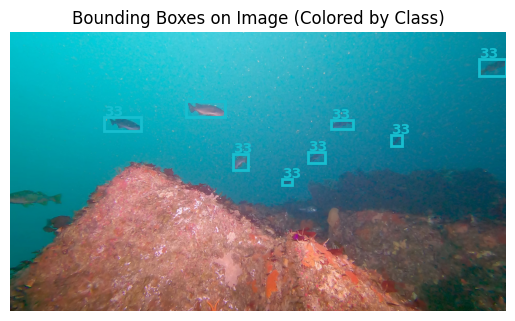

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# load the image
image = Image.open(os.path.join(working_dir, 'model', 'val', 'images', first_val_img)).convert('RGB')

# define image width and height
image_width = np.shape(image)[1]
image_height = np.shape(image)[0]

# Get the class IDs from the results object
classes = results[0].boxes.cls.cpu().numpy()

# ---- example assumptions ----
# boxes: shape (N, 4) in YOLO format [x_center, y_center, width, height] (normalized)
# classes: shape (N,) with class IDs
# --------------------------------

# create color map per class
num_classes = int(np.max(classes)) + 1
cmap = plt.cm.get_cmap('tab10', num_classes)
class_colors = {i: cmap(i) for i in range(num_classes)}

# function to draw bounding box
def plot_bounding_box(ax, img_w, img_h, box, class_id, color):
    x_center, y_center, w, h = box

    # convert from YOLO normalized format to pixel coords
    x = (x_center - w / 2) * img_w
    y = (y_center - h / 2) * img_h
    w = w * img_w
    h = h * img_h

    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2,
        edgecolor=color,
        facecolor='none'
    )
    ax.add_patch(rect)

    # draw class label
    ax.text(x, y - 5, str(class_id),
            color=color, fontsize=10, weight='bold')

# plot the figure
fig, ax = plt.subplots()
ax.imshow(image)

# draw all boxes with class-based colors
for ll in range(np.shape(boxes)[0]):
    extent = np.copy(boxes[ll, :])
    class_id = int(classes[ll])
    color = class_colors[class_id]

    plot_bounding_box(ax, image_width, image_height, extent, class_id, color)

plt.title('Bounding Boxes on Image (Colored by Class)')
plt.axis('off')
plt.show()

Here we can see that our model is identifying the Rockfish (1) in this image as well as the smaller fish in the background and the algae and sponge that the original model was identifying as fish.

##ITERATIVE IMPROVEMENT

Our model is doing well and identifying what we want! This is a success!

We can now use this model on more video to extract information like # of rockfish seen in the frame, maximum # of a certain species, etc.

But, we can also use this model to create more training data and improve the model. We can use this model to draw bounding boxes on another video, and go through manually validating and labeling more frames to improve the model.

Another option is to start labeling the Rockfish by species in order to create a model that can ID to the species level.

**To create more training data we will follow the same steps above, except we will use our newly trained model and apply it to a new video**

In [ ]:
from ultralytics import YOLO
import os
import cv2

# Paths
model_path = os.path.join(working_dir, 'model/fish/weights/best.pt') #NEW MODEL
video_path = os.path.join(working_dir, "20220726_ButterflyHouse_D14.03_6R_2.MP4") #AND NEW VIDEO

out_frames = os.path.join(working_dir, "Second_video","Initial_frames_v2")
out_labels = os.path.join(working_dir, "Second_video","Initial_labels_v2")

os.makedirs(out_frames, exist_ok=True)
os.makedirs(out_labels, exist_ok=True)

# Load model
model = YOLO(model_path)

# Run prediction
results = model.predict(
    source=video_path,
    agnostic_nms=True,
    save=False,
    save_txt=False,   # we're saving txt ourselves below
    conf=0.09, #we keep confidence low so that the model is not too picky
    iou=0.15,
    imgsz=1080,
    max_det=1000,
    half=True,
    classes=[0, 1, 2, 3],
    vid_stride=60, #takes a frame very second
    device="cuda",
    stream=True
)

for i, r in enumerate(results):
    base = f"frame_{i:06d}"

    # 1) Save clean frame (no boxes)
    img_path = os.path.join(out_frames, f"{base}.jpg")
    cv2.imwrite(img_path, r.orig_img)

    # 2) Save matching YOLO label file
    txt_path = os.path.join(out_labels, f"{base}.txt")

    lines = []
    if r.boxes is not None and len(r.boxes) > 0:
        # normalized xywh (0-1) in YOLO format
        xywhn = r.boxes.xywhn.cpu().numpy()
        cls = r.boxes.cls.cpu().numpy().astype(int)

        for c, (x, y, w, h) in zip(cls, xywhn):
            lines.append(f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")

    with open(txt_path, "w") as f:
        f.write("\n".join(lines))

Now that we have used our model to predict on a new video, the next step is to import the frames and labels into RectLabel. In RectLabel, I will go through and correct any mistakes and add labels for anything missed. Finally, I will consolidate this dataset with the original one to create a larger more robust training set. I will then retrain a YOLO model on this larger and better dataset.

##Consolidating datasets

In [ ]:
from pathlib import Path

root = Path(working_dir)

print("Exists:", root.exists())
print("\nTop-level contents of /content:")
for p in sorted(root.iterdir()):
    print("-", p.name)

In [ ]:
from pathlib import Path
import shutil

# ====== CONFIG ======
working_dir = Path("/content/drive/MyDrive/MS285/final_project")

DATASET1 = working_dir / "Fish_Sebastest_Other_04162026"
DATASET2 = working_dir / "Second_video"
OUTPUT = working_dir / "merged_dataset"

PREFIX1 = "ds1"
PREFIX2 = "ds2"

IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
# ====================


def find_image_for_label(label_path: Path, images_dir: Path):
    stem = label_path.stem
    for ext in IMAGE_EXTS:
        candidate = images_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None


def copy_dataset(dataset_root: Path, prefix: str, output_root: Path):
    images_in = dataset_root / "images"
    labels_in = dataset_root / "labels"

    if not dataset_root.exists():
        print(f"[ERROR] Dataset folder not found: {dataset_root}")
        return

    if not images_in.exists():
        print(f"[ERROR] Images folder not found: {images_in}")
        return

    if not labels_in.exists():
        print(f"[ERROR] Labels folder not found: {labels_in}")
        return

    images_out = output_root / "images"
    labels_out = output_root / "labels"
    images_out.mkdir(parents=True, exist_ok=True)
    labels_out.mkdir(parents=True, exist_ok=True)

    label_files = sorted(labels_in.glob("*.txt"))
    print(f"[INFO] Processing {len(label_files)} labels from {dataset_root.name}")

    for label_file in label_files:
        image_file = find_image_for_label(label_file, images_in)
        if image_file is None:
            print(f"[WARN] No matching image for {label_file.name}")
            continue

        new_stem = f"{prefix}_{label_file.stem}"
        out_image = images_out / f"{new_stem}{image_file.suffix.lower()}"
        out_label = labels_out / f"{new_stem}.txt"

        counter = 1
        while out_image.exists() or out_label.exists():
            unique_stem = f"{new_stem}_{counter}"
            out_image = images_out / f"{unique_stem}{image_file.suffix.lower()}"
            out_label = labels_out / f"{unique_stem}.txt"
            counter += 1

        shutil.copy2(image_file, out_image)
        shutil.copy2(label_file, out_label)

    print(f"[DONE] Finished {dataset_root.name}")


def main():
    copy_dataset(DATASET1, PREFIX1, OUTPUT)
    copy_dataset(DATASET2, PREFIX2, OUTPUT)
    print(f"\nMerged dataset written to: {OUTPUT.resolve()}")


if __name__ == "__main__":
    main()

This code consolidated our two datasets so we can now train another model with our bigger, better dataset. Before we start training we have to split our new dataset into train and val sets.

In [ ]:
# make some directories for the data
os.makedirs(os.path.join(working_dir,'model_2','train'), exist_ok=True)
os.makedirs(os.path.join(working_dir,'model_2','val'), exist_ok=True)

# split the images into training and testing
image_files = [f for f in sorted(os.listdir(os.path.join(working_dir,'merged_dataset/images'))) if f.endswith('.jpg')]
train_files, val_files = train_test_split(
    image_files,
    test_size=0.2,
    random_state=17
)

# copy the training files
for split,file_list in zip(['train','val'], [train_files, val_files]):
    os.makedirs(os.path.join(working_dir,'model_2',split,'images'), exist_ok=True)
    os.makedirs(os.path.join(working_dir,'model_2',split,'labels'), exist_ok=True)

    for file_name in file_list:
        shutil.copy(os.path.join(working_dir,'merged_dataset/images',file_name),
                    os.path.join(working_dir,'model_2',split,'images',file_name))

        label_file = file_name.replace(".jpg", ".txt")
        shutil.copy(os.path.join(working_dir,'merged_dataset/labels',label_file),
                    os.path.join(working_dir,'model_2',split,'labels',label_file))







In [ ]:
# define the configuration data as a dictionary
config = {
    'path': os.path.join(working_dir,'model_2'),
    'train': 'train/images',   # train images (relative to 'path') 4 images
    'val': 'val/images',       # val images (relative to 'path') 4 images
    'nc': 4,                   # Number of classes
    'names': ['Fish','Sebastes','Algae','Sponge'],         # Class names
}

# write the YAML data to the file
with open(os.path.join(working_dir,'model_2','config.yaml'), 'w') as yaml_file:
    yaml.dump(config, yaml_file)

Now we can start training again!

In [ ]:
model = YOLO('yolov8s.pt')

In [ ]:
if home_dir=='/root': # be sure to only do this on colab [it will crash your Jupyter kernel on your laptop :)]
    results = model.train(data=os.path.join(working_dir,'model_2','config.yaml'),
                          epochs=40,
                          project=os.path.join(working_dir,'model_2'),
                          imgsz=640,
                          pretrained = True ,
                          name= "fish",
                          patience = 35,
                          flipud=0.5,
                          batch = 32,
                          optimizer = 'SGD',
                          augment = True
                          )

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/MS285/final_project/model_2/config.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fish-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, ove

Lets take a look at the loss and performance of the model

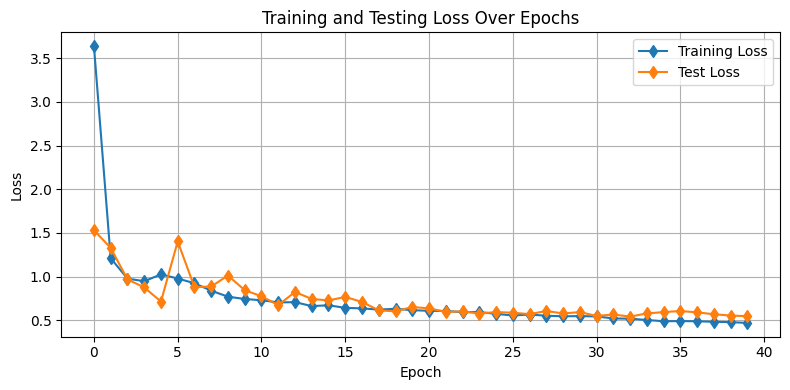

In [ ]:
results_vid=pd.read_csv(os.path.join(working_dir,'model_2/fish-2/results.csv'))

train_losses=results_vid['train/cls_loss']
test_losses=results_vid['val/cls_loss']

plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'd-', label='Training Loss')
plt.plot(test_losses, 'd-', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Our losses look good! Our model is performing better after each epoch. We could train our model for more epochs to get even better peformance, but this will take a long time

Now that we have trained our model on a new, larger, and hopefully better dataset, we can use it to identify rockfish in another video. Once identified, we can count the number of rockfish in each frame in order to help us with our MaxN abundance counts.

In [41]:
from ultralytics import YOLO
import os
import cv2

# Paths
model_path = os.path.join(working_dir, 'model_2/fish-2/weights/best.pt') #NEW MODEL
video_path = os.path.join(working_dir, "20220727_ButterflyHouse_D16.04_7L_4.MP4") #AND NEW VIDEO

out_frames = os.path.join(working_dir, "Primary_Analysis","Frames")
out_labels = os.path.join(working_dir, "Primary_Analysis","Labels")

os.makedirs(out_frames, exist_ok=True)
os.makedirs(out_labels, exist_ok=True)

# Load model
model = YOLO(model_path)

# Run prediction and convert the generator to a list to avoid re-running predictions
video_prediction_results = list(model.predict(
    source=video_path,
    agnostic_nms=True,
    save=False,
    save_txt=False,   # we're saving txt ourselves below
    conf=0.5, #we keep confidence low so that the model is not too picky
    iou=0.15,
    imgsz=1080,
    max_det=1000,
    half=True,
    classes=[0, 1, 2, 3],
    vid_stride=60, #takes a frame very second
    device="cuda",
    stream=True
))

for i, r in enumerate(video_prediction_results):
    base = f"frame_{i:06d}"

    # 1) Save clean frame (no boxes)
    img_path = os.path.join(out_frames, f"{base}.jpg")
    cv2.imwrite(img_path, r.orig_img)

    # 2) Save matching YOLO label file
    txt_path = os.path.join(out_labels, f"{base}.txt")

    lines = []
    if r.boxes is not None and len(r.boxes) > 0:
        # normalized xywh (0-1) in YOLO format
        xywhn = r.boxes.xywhn.cpu().numpy()
        cls = r.boxes.cls.cpu().numpy().astype(int)

        for c, (x, y, w, h) in zip(cls, xywhn):
            lines.append(f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")

    with open(txt_path, "w") as f:
        f.write("\n".join(lines))


WARNING ⚠️ imgsz=[1080] must be multiple of max stride 32, updating to [1088]
video 1/1 (frame 1/354) /content/drive/MyDrive/MS285/final_project/20220727_ButterflyHouse_D16.04_7L_4.MP4: 640x1088 2 Sebastess, 34.5ms
video 1/1 (frame 2/354) /content/drive/MyDrive/MS285/final_project/20220727_ButterflyHouse_D16.04_7L_4.MP4: 640x1088 3 Sebastess, 12.0ms
video 1/1 (frame 3/354) /content/drive/MyDrive/MS285/final_project/20220727_ButterflyHouse_D16.04_7L_4.MP4: 640x1088 3 Sebastess, 22.0ms
video 1/1 (frame 4/354) /content/drive/MyDrive/MS285/final_project/20220727_ButterflyHouse_D16.04_7L_4.MP4: 640x1088 4 Sebastess, 12.0ms
video 1/1 (frame 5/354) /content/drive/MyDrive/MS285/final_project/20220727_ButterflyHouse_D16.04_7L_4.MP4: 640x1088 5 Sebastess, 12.0ms
video 1/1 (frame 6/354) /content/drive/MyDrive/MS285/final_project/20220727_ButterflyHouse_D16.04_7L_4.MP4: 640x1088 4 Sebastess, 12.1ms
video 1/1 (frame 7/354) /content/drive/MyDrive/MS285/final_project/20220727_ButterflyHouse_D16.04_7

KeyboardInterrupt: 

Now that our model has been used to predict some labels in this new unseen video lets print out some examples

In [ ]:
model = YOLO(os.path.join(working_dir,'model_2/fish-2/weights/best.pt'))

/tmp/ipykernel_790/44737359.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', num_classes)


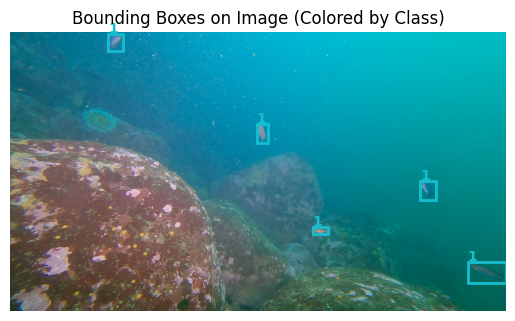

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO # Import YOLO if not already imported in this scope

# identify a test image file path
image_file_path = os.path.join(working_dir,'Primary_Analysis','Frames','frame_000076.jpg')

# make some predictions for this test image
# this might give you some warnings, but it is ok to ignore them
results = model.predict(image_file_path, conf=0.4,classes=[1],verbose=False)

# get the bounding box
boxes = results[0].boxes.xywhn.cpu().numpy()

# get the confidence values
confidences = results[0].boxes.conf.cpu().numpy()

# load the image
image = Image.open(image_file_path).convert('RGB')

# define image width and height
image_width = np.shape(image)[1]
image_height = np.shape(image)[0]

# Get the class IDs from the results object
classes = results[0].boxes.cls.cpu().numpy()

# ---- example assumptions ----
# boxes: shape (N, 4) in YOLO format [x_center, y_center, width, height] (normalized)
# classes: shape (N,) with class IDs
# --------------------------------

# create color map per class
# Ensure num_classes is correctly calculated based on the available classes or known total
# If classes array is empty, np.max will throw an error. Handle this case.
num_classes = int(np.max(classes)) + 1 if classes.size > 0 else 1 # Default to at least 1 class
cmap = plt.cm.get_cmap('tab10', num_classes)
class_colors = {i: cmap(i) for i in range(num_classes)}

# function to draw bounding box
def plot_bounding_box(ax, img_w, img_h, box, class_id, color):
    x_center, y_center, w, h = box

    # convert from YOLO normalized format to pixel coords
    x = (x_center - w / 2) * img_w
    y = (y_center - h / 2) * img_h
    w = w * img_w
    h = h * img_h

    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2,
        edgecolor=color,
        facecolor='none'
    )
    ax.add_patch(rect)

    # draw class label
    ax.text(x, y - 5, str(class_id),
            color=color, fontsize=10, weight='bold')

# plot the figure
fig, ax = plt.subplots()
ax.imshow(image)

# draw all boxes with class-based colors
for ll in range(np.shape(boxes)[0]):
    extent = np.copy(boxes[ll, :])
    class_id = int(classes[ll])
    color = class_colors[class_id]

    plot_bounding_box(ax, image_width, image_height, extent, class_id, color)

plt.title('Bounding Boxes on Image (Colored by Class)')
plt.axis('off')
plt.show()

As we can see the model identified 5 fish in our frame and it did a great job!. We set our confidence relatively low, so we may get some things that are not infact fish.

Our model is performing pretty well, so lets try and count how many fish we see in each frame in a new video

In [53]:
##HUH
import numpy as np

# The 'video_prediction_results' variable from cell KjKAa5wyUTo1
# contains the predictions for the video across all classes.

fish_counts = []
confidence_threshold = 0.5 # Set a confidence threshold for detections
for r in video_prediction_results: # Use the correct variable for video predictions
    if r.boxes is not None and len(r.boxes) > 0:
        # Get class IDs and confidences for current frame's detections
        class_ids = r.boxes.cls.cpu().numpy().astype(int)
        confidences = r.boxes.conf.cpu().numpy()

        # Filter for 'Sebastes' (class 1) and apply confidence threshold
        sebastes_detections = (class_ids == 1) & (confidences >= confidence_threshold)
        sebastes_count = np.sum(sebastes_detections)
        fish_counts.append(sebastes_count)
    else:
        fish_counts.append(0) # No detections in this frame

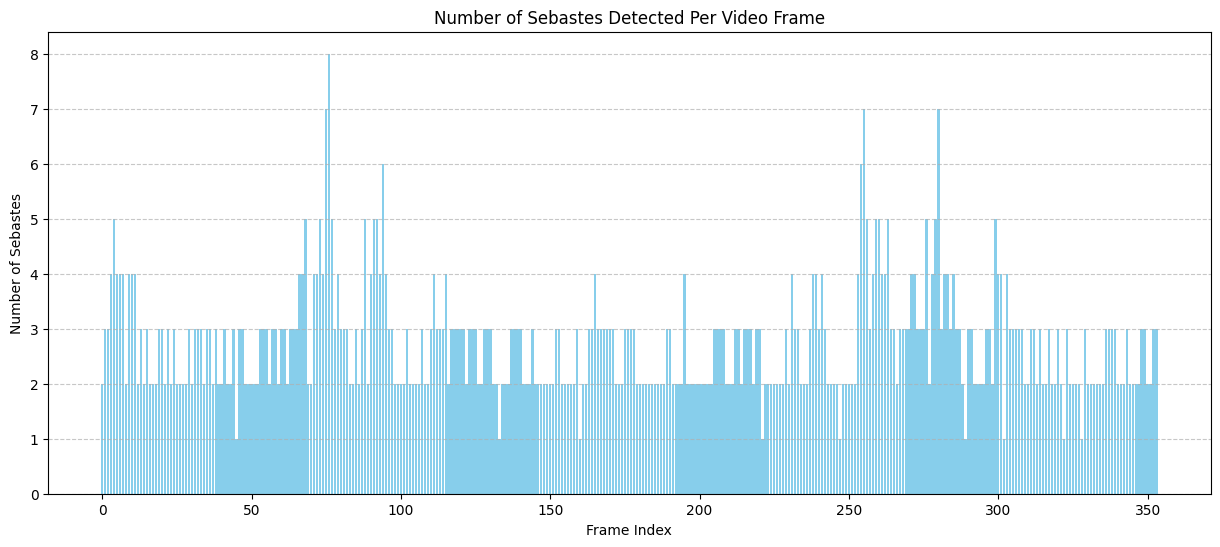

In [54]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))
plt.bar(np.arange(len(fish_counts)), fish_counts, width=0.8, color='skyblue')
plt.xlabel('Frame Index')
plt.ylabel('Number of Sebastes')
plt.title('Number of Sebastes Detected Per Video Frame')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Now we have the labeled sebastes (hopefully all of them) from our model for every frame in our video. According to our model, the MaxN of rockfish from this video is 8 around frame 75. Lets find exactly what frame this is and take a look.

The frame with the maximum number of Sebastes is frame index 76 with 8 detections.
Number of Sebastes bounding boxes about to be plotted: 8


/tmp/ipykernel_790/259878074.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_plot = plt.cm.get_cmap('tab10', num_classes_plot)


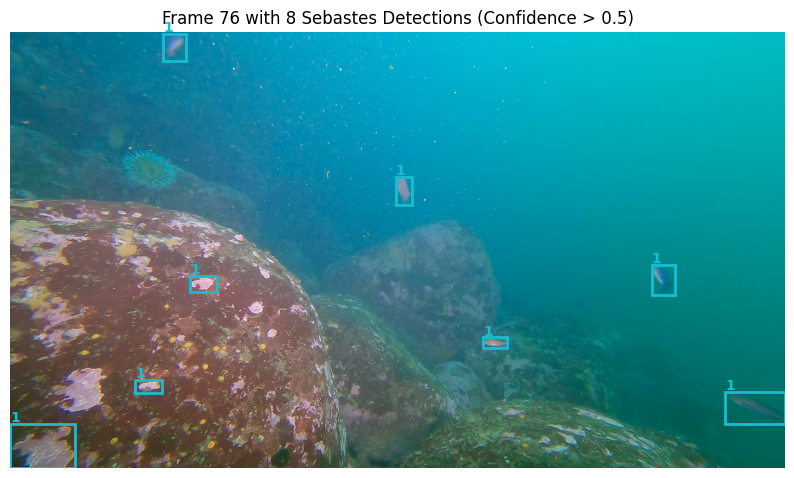

In [55]:
max_sebastes_frame_index = np.argmax(fish_counts)
max_sebastes_count = fish_counts[max_sebastes_frame_index]

confidence_threshold = 0.5 # Ensure this matches the threshold used for fish_counts

print(f"The frame with the maximum number of Sebastes is frame index {max_sebastes_frame_index} with {max_sebastes_count} detections.")

# Construct the image file path for the max Sebastes frame
max_sebastes_image_filename = f"frame_{max_sebastes_frame_index:06d}.jpg"
image_file_path_max_sebastes = os.path.join(working_dir, 'Primary_Analysis', 'Frames', max_sebastes_image_filename)

# Load the image
image_max_sebastes = Image.open(image_file_path_max_sebastes).convert('RGB')
image_width_max_sebastes = np.shape(image_max_sebastes)[1]
image_height_max_sebastes = np.shape(image_max_sebastes)[0]

# IMPORTANT MODIFICATION: Use the pre-computed results from video_prediction_results
# Get the raw predictions for this specific frame from the list generated earlier
raw_frame_results = video_prediction_results[max_sebastes_frame_index]

boxes_to_plot = []
classes_to_plot = []

if raw_frame_results.boxes is not None and len(raw_frame_results.boxes) > 0:
    # Iterate through all detections in this raw frame result
    for box, cls_id, conf in zip(raw_frame_results.boxes.xywhn.cpu().numpy(),
                                  raw_frame_results.boxes.cls.cpu().numpy(),
                                  raw_frame_results.boxes.conf.cpu().numpy()):
        # Only add detections that are 'Sebastes' (class 1) and meet the confidence threshold
        if int(cls_id) == 1 and conf >= confidence_threshold:
            boxes_to_plot.append(box)
            classes_to_plot.append(cls_id)

# Convert lists to numpy arrays; handle case where no detections meet criteria
boxes_max_sebastes = np.array(boxes_to_plot) if boxes_to_plot else np.empty((0, 4))
classes_max_sebastes = np.array(classes_to_plot) if classes_to_plot else np.empty((0,))

# Print the actual number of boxes about to be plotted for verification
print(f"Number of Sebastes bounding boxes about to be plotted: {len(boxes_max_sebastes)}")

# Create color map per class
# Ensure num_classes_plot is robust to empty classes_max_sebastes
num_classes_plot = int(np.max(classes_max_sebastes)) + 1 if classes_max_sebastes.size > 0 else 1
cmap_plot = plt.cm.get_cmap('tab10', num_classes_plot)
class_colors_plot = {i: cmap_plot(i) for i in range(num_classes_plot)}

# Plot the figure
fig_max, ax_max = plt.subplots(figsize=(10, 7))
ax_max.imshow(image_max_sebastes)

# Draw all boxes with class-based colors
if boxes_max_sebastes.size > 0: # Only iterate if there are boxes to plot
    for ll in range(np.shape(boxes_max_sebastes)[0]):
        extent_max = np.copy(boxes_max_sebastes[ll, :])
        class_id_max = int(classes_max_sebastes[ll])
        color_max = class_colors_plot[class_id_max]
        plot_bounding_box(ax_max, image_width_max_sebastes, image_height_max_sebastes, extent_max, class_id_max, color_max)

ax_max.set_title(f'Frame {max_sebastes_frame_index} with {max_sebastes_count} Sebastes Detections (Confidence > {confidence_threshold})')
ax_max.axis('off')
plt.show()

As we can see there are 5 fish in this frame and 3 pink blotches have been labeled as Rock fish. Our model is not perfect, but it did label all of the Rock fish seen in the video. This illustrates that this model is not perfect and should be iterate on. We can label even more images and continue to improve our training dataset.

Another option we can do is increase our confidence threshold so only labels that the model is sure are Rockfish are included.

Lets try to up our confidence interval from 0.5 to 0.8

In [56]:
##HUH
import numpy as np

# The 'video_prediction_results' variable from cell KjKAa5wyUTo1
# contains the predictions for the video across all classes.

fish_counts_conf = []
confidence_threshold = 0.8 # Set a confidence threshold for detections
for r in video_prediction_results: # Use the correct variable for video predictions
    if r.boxes is not None and len(r.boxes) > 0:
        # Get class IDs and confidences for current frame's detections
        class_ids = r.boxes.cls.cpu().numpy().astype(int)
        confidences = r.boxes.conf.cpu().numpy()

        # Filter for 'Sebastes' (class 1) and apply confidence threshold
        sebastes_detections = (class_ids == 1) & (confidences >= confidence_threshold)
        sebastes_count = np.sum(sebastes_detections)
        fish_counts_conf.append(sebastes_count)
    else:
        fish_counts_conf.append(0) # No detections in this frame

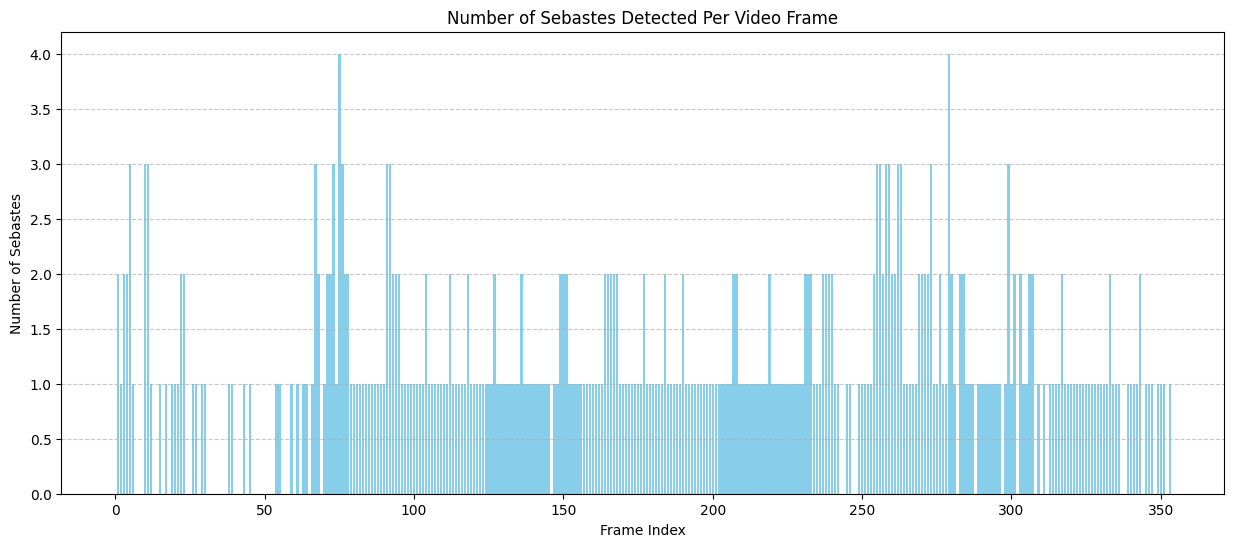

In [58]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))
plt.bar(np.arange(len(fish_counts_conf)), fish_counts_conf, width=0.8, color='skyblue')
plt.xlabel('Frame Index')
plt.ylabel('Number of Sebastes')
plt.title('Number of Sebastes Detected Per Video Frame')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

As we can see the number of Sebastes detected per frame is much less when our confidence interval is higher.

Lets take a look at the max now.

The frame with the maximum number of Sebastes is frame index 75 with 4 detections.
Number of Sebastes bounding boxes about to be plotted: 4


/tmp/ipykernel_790/4007020343.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_plot = plt.cm.get_cmap('tab10', num_classes_plot)


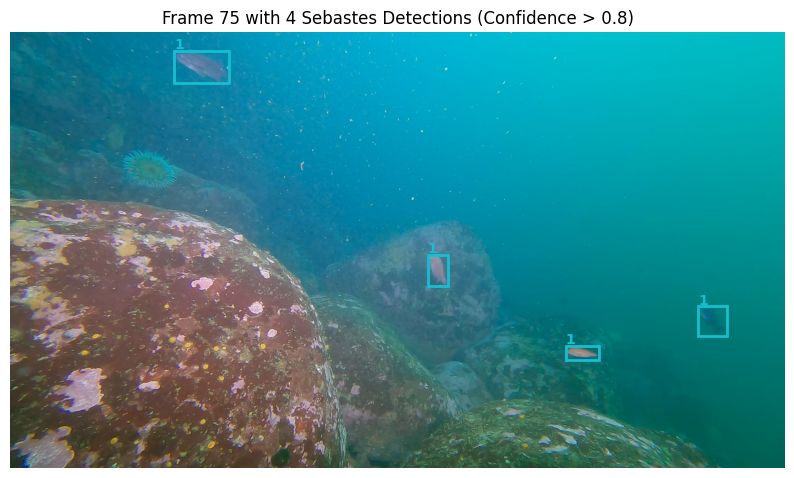

In [57]:
max_sebastes_frame_index = np.argmax(fish_counts_conf)
max_sebastes_count = fish_counts_conf[max_sebastes_frame_index]

confidence_threshold = 0.8 # Ensure this matches the threshold used for fish_counts

print(f"The frame with the maximum number of Sebastes is frame index {max_sebastes_frame_index} with {max_sebastes_count} detections.")

# Construct the image file path for the max Sebastes frame
max_sebastes_image_filename = f"frame_{max_sebastes_frame_index:06d}.jpg"
image_file_path_max_sebastes = os.path.join(working_dir, 'Primary_Analysis', 'Frames', max_sebastes_image_filename)

# Load the image
image_max_sebastes = Image.open(image_file_path_max_sebastes).convert('RGB')
image_width_max_sebastes = np.shape(image_max_sebastes)[1]
image_height_max_sebastes = np.shape(image_max_sebastes)[0]

# IMPORTANT MODIFICATION: Use the pre-computed results from video_prediction_results
# Get the raw predictions for this specific frame from the list generated earlier
raw_frame_results = video_prediction_results[max_sebastes_frame_index]

boxes_to_plot = []
classes_to_plot = []

if raw_frame_results.boxes is not None and len(raw_frame_results.boxes) > 0:
    # Iterate through all detections in this raw frame result
    for box, cls_id, conf in zip(raw_frame_results.boxes.xywhn.cpu().numpy(),
                                  raw_frame_results.boxes.cls.cpu().numpy(),
                                  raw_frame_results.boxes.conf.cpu().numpy()):
        # Only add detections that are 'Sebastes' (class 1) and meet the confidence threshold
        if int(cls_id) == 1 and conf >= confidence_threshold:
            boxes_to_plot.append(box)
            classes_to_plot.append(cls_id)

# Convert lists to numpy arrays; handle case where no detections meet criteria
boxes_max_sebastes = np.array(boxes_to_plot) if boxes_to_plot else np.empty((0, 4))
classes_max_sebastes = np.array(classes_to_plot) if classes_to_plot else np.empty((0,))

# Print the actual number of boxes about to be plotted for verification
print(f"Number of Sebastes bounding boxes about to be plotted: {len(boxes_max_sebastes)}")

# Create color map per class
# Ensure num_classes_plot is robust to empty classes_max_sebastes
num_classes_plot = int(np.max(classes_max_sebastes)) + 1 if classes_max_sebastes.size > 0 else 1
cmap_plot = plt.cm.get_cmap('tab10', num_classes_plot)
class_colors_plot = {i: cmap_plot(i) for i in range(num_classes_plot)}

# Plot the figure
fig_max, ax_max = plt.subplots(figsize=(10, 7))
ax_max.imshow(image_max_sebastes)

# Draw all boxes with class-based colors
if boxes_max_sebastes.size > 0: # Only iterate if there are boxes to plot
    for ll in range(np.shape(boxes_max_sebastes)[0]):
        extent_max = np.copy(boxes_max_sebastes[ll, :])
        class_id_max = int(classes_max_sebastes[ll])
        color_max = class_colors_plot[class_id_max]
        plot_bounding_box(ax_max, image_width_max_sebastes, image_height_max_sebastes, extent_max, class_id_max, color_max)

ax_max.set_title(f'Frame {max_sebastes_frame_index} with {max_sebastes_count} Sebastes Detections (Confidence > {confidence_threshold})')
ax_max.axis('off')
plt.show()

Now we can see that there are 4 fish labeled correctly and those pink blotches are not included!

Our model is doing pretty well! This is a great tool to run your videos on to get a good idea of where the most fish seen in the frame are.

This model is obviously limited as it is not trained by species yet. This is the ultimate goal, but would require a ton of training data and a lot more than I have right now. If we wanted our model to perform as well as it is now, we would expect to need the same amount of images in our set for each species of interest. This is the next step and I hope to continue working on this project.